# Wanderbricks Cancellation Predictor
## Databricks ML Overview — Training Session

**Business scenario:** You are a data scientist at Wanderbricks, a fictional travel booking platform. The customer operations team has flagged rising cancellation rates. Your job: build a model that predicts which new bookings are likely to cancel so the team can intervene early with reminders or incentives.

**What we cover:**
1. Explore data in the `samples` catalog
2. Engineer features using Apache Spark
3. Train a classification model with **MLflow autologging**
4. Review the MLflow Experiment UI
5. Evaluate the model
6. Save and reload the model using MLflow
7. Understand how CI/CD fits into the Databricks ML workflow

> **Workspace:** Databricks Individual (free) edition.  
> Steps marked **Paid feature** describe capabilities available in paid or trial workspaces.

In [0]:
%pip install xgboost

Looking in indexes: [REDACTED]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 MB 117.3 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# All libraries are pre-installed in Databricks Runtime — no pip install needed
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, ConfusionMatrixDisplay,
    precision_score, recall_score,
)

print('MLflow version:', mlflow.__version__)


MLflow version: 3.8.1


---
## Section 1 — Explore the Data

We read directly from the `samples` catalog — no connection strings, no JDBC setup required.  
Unity Catalog governs access automatically.

**`display()` vs `.show()`:** Always use `display()` in Databricks notebooks. It renders an interactive table with column sorting, filtering, and a built-in chart builder.

In [0]:
bookings_raw = spark.read.table('samples.wanderbricks.bookings')
display(bookings_raw)

booking_id,user_id,property_id,check_in,check_out,guests_count,total_amount,status,created_at,updated_at
18158,104276,4749,2024-12-11,2024-12-15,1,879.15,confirmed,2024-12-04T05:28:55.000Z,2024-12-06T22:54:47.000Z
18159,102433,8618,2024-10-06,2024-10-10,3,451.33,pending,2024-01-05T13:02:52.000Z,2024-02-06T00:11:03.000Z
18160,43834,11881,2024-12-14,2024-12-18,3,593.59,pending,2024-11-10T15:31:49.000Z,2024-12-12T10:19:16.000Z
18161,27968,8660,2025-07-27,2025-07-30,2,983.69,pending,2025-07-27T23:59:59.000Z,2025-07-27T23:59:59.000Z
18162,90588,6271,2024-06-16,2024-06-21,1,495.79,pending,2023-10-10T04:18:20.000Z,2023-10-21T09:18:42.000Z
18163,46691,11733,2025-06-11,2025-06-16,1,771.19,confirmed,2025-05-28T12:12:41.000Z,2025-06-11T18:43:07.000Z
18164,51555,10366,2025-04-06,2025-04-12,2,959.69,confirmed,2025-03-29T17:09:03.000Z,2025-04-03T03:07:47.000Z
18165,37876,6452,2025-05-18,2025-05-22,2,654.3,pending,2025-05-01T14:05:54.000Z,2025-05-18T23:59:56.000Z
18166,25051,11460,2025-06-22,2025-06-25,1,844.5,cancelled,2025-04-11T12:46:47.000Z,2025-06-02T05:28:24.000Z
18167,106864,6039,2025-04-04,2025-04-09,1,995.18,cancelled,2025-04-04T04:24:44.000Z,2025-04-04T21:52:22.000Z


In [0]:
%sql
SELECT status, COUNT(*) AS booking_count
FROM samples.wanderbricks.bookings
GROUP BY status
ORDER BY booking_count DESC

status,booking_count
pending,31575
confirmed,17948
cancelled,15285
completed,7439


In [0]:
%sql
-- Run this first! Verify column names match what the feature engineering code expects.
-- Adjust column names in Section 2 if your schema differs.
DESCRIBE TABLE samples.wanderbricks.bookings

col_name,data_type,comment
booking_id,bigint,Unique identifier of the booking
user_id,bigint,The identifier of the user making the booking
property_id,bigint,Foreign Key to 'properties'
check_in,date,Check-in date
check_out,date,Check-out date
guests_count,int,Number of guests for booking
total_amount,float,Total amount paid
status,string,"Status of the booking (e.g., pending, confirmed)"
created_at,timestamp,Date the booking was created
updated_at,timestamp,Date the booking was last updated


---
## Section 2 — Feature Engineering with Spark

We join four tables with `bookings` as the anchor, derive new columns using `pyspark.sql.functions`, then convert to Pandas for scikit-learn.

| Join | Purpose |
|---|---|
| `bookings → users` | User tenure, age, loyalty tier |
| `bookings → properties` | Property type and average rating |
| `bookings → payments` | Payment method and timing |

> **Why LEFT JOIN?** Not every booking has a completed payment record. Left joins preserve all bookings and let us handle nulls explicitly.

> **Why NOT join `reviews`?** Reviews are written *after* the stay. Using them to predict cancellation would be **data leakage** — the model would train on information it cannot have at prediction time.

In [0]:
from pyspark.sql import functions as F

bookings   = spark.read.table('samples.wanderbricks.bookings')
users      = spark.read.table('samples.wanderbricks.users')
properties = spark.read.table('samples.wanderbricks.properties')
payments   = spark.read.table('samples.wanderbricks.payments')

print('Bookings  :', bookings.count())
print('Users     :', users.count())
print('Properties:', properties.count())
print('Payments  :', payments.count())

Bookings  : 72247
Users     : 124509
Properties: 18163
Payments  : 49638


In [0]:
# --- Join tables (bookings is the anchor) ---
df = (
    bookings
    .join(users.select('user_id', F.col('created_at').alias('user_created_at'), 'country'),
          on='user_id', how='left')
    .join(properties.select('property_id', 'property_type', 'bedrooms', 'base_price'),
          on='property_id', how='left')
    .join(payments.select('booking_id', 'payment_method', 'payment_date'),
          on='booking_id', how='left')
)

# --- Derive features (created_at here is bookings.created_at = booking date) ---
df = (
    df
    # Target variable: 1 = cancelled, 0 = everything else
    .withColumn('is_cancelled',
                F.when(F.col('status') == 'cancelled', 1).otherwise(0))
    # Days between booking date and check-in (longer lead = higher cancel risk)
    .withColumn('lead_time_days',
                F.datediff(F.col('check_in'), F.col('created_at')))
    # Length of the stay in nights
    .withColumn('length_of_stay',
                F.datediff(F.col('check_out'), F.col('check_in')))
    # Month of booking (captures seasonality)
    .withColumn('booking_month',
                F.month(F.col('created_at')))
    # How long the user has been a member at time of booking
    .withColumn('user_tenure_days',
                F.datediff(F.col('created_at'), F.col('user_created_at')))
    # Days between booking and payment (delayed payment is a cancel signal)
    .withColumn('days_to_payment',
                F.datediff(F.col('payment_date'), F.col('created_at')))
)

# --- Select final feature set ---
feature_cols = [
    'is_cancelled',
    'lead_time_days', 'length_of_stay', 'total_amount', 'guests_count', 'booking_month',
    'user_tenure_days', 'country',
    'property_type', 'bedrooms', 'base_price',
    'payment_method', 'days_to_payment',
]

df_features = df.select(*feature_cols)
display(df_features.limit(10))

is_cancelled,lead_time_days,length_of_stay,total_amount,guests_count,booking_month,user_tenure_days,country,property_type,bedrooms,base_price,payment_method,days_to_payment
0,7,4,879.15,1,12,280,Egypt,Urban Year-Round,1,137.36,credit_card,2
0,275,4,451.33,3,1,-385,Nigeria,Urban Year-Round,2,221.62,bank_transfer,262
0,34,4,593.59,3,11,38,Japan,Urban Year-Round,1,110.23,credit_card,34
0,0,3,983.69,2,7,490,Brazil,Summer Getaway,1,170.5,google_pay,0
0,250,5,495.79,1,10,-61,China,Summer Getaway,1,171.96,paypal,81
0,14,5,771.19,1,5,785,India,Summer Getaway,1,126.29,google_pay,14
0,8,6,959.69,2,3,467,India,Urban Year-Round,1,190.63,credit_card,5
0,17,4,654.3,2,5,17,United States,Urban Year-Round,2,282.29,google_pay,17
1,72,3,844.5,1,4,498,Sri Lanka,Urban Year-Round,1,111.79,null,null
1,0,5,995.18,1,4,363,China,Urban Year-Round,2,193.77,null,null


In [0]:
# Convert to Pandas for scikit-learn
# Fine for a sample dataset; in production keep everything in Spark or use Spark MLlib
df_pd = df_features.toPandas()

print('Shape:', df_pd.shape)
print('Cancellation rate: {:.1%}'.format(df_pd['is_cancelled'].mean()))
print('\nNull counts:')
print(df_pd.isnull().sum())

Shape: (75927, 13)
Cancellation rate: 21.1%

Null counts:
is_cancelled            0
lead_time_days          0
length_of_stay          0
total_amount            0
guests_count            0
booking_month           0
user_tenure_days        0
country                 0
property_type           0
bedrooms                0
base_price              0
payment_method      26297
days_to_payment     26297
dtype: int64


In [0]:
# One-hot encode categoricals
categorical_cols = ['property_type', 'payment_method', 'country']
df_model = pd.get_dummies(df_pd, columns=categorical_cols, drop_first=True)

# Fill nulls from left joins with 0
df_model = df_model.fillna(0)

X = df_model.drop('is_cancelled', axis=1)
y = df_model['is_cancelled']

# stratify=y ensures both splits have the same cancellation rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train), ' | Test samples:', len(X_test))
print('Cancellation rate in train: {:.1%}'.format(y_train.mean()))
print('Number of features:', X.shape[1])

Training samples: 60741  | Test samples: 15186
Cancellation rate in train: 21.1%
Number of features: 179


---
## Section 3 — Train with MLflow Autologging

`mlflow.sklearn.autolog()` is the single most impactful Databricks ML feature for beginners.  
**One line** automatically captures:
- All model hyperparameters (`C`, `max_iter`, `solver`, …)
- Training metrics (accuracy, F1, precision, recall)
- The serialised model artifact
- Feature coefficients

Without autolog, you would write 20+ `mlflow.log_param()` calls by hand.

---

**Why Logistic Regression as the baseline?**  
Always start with the simplest model that could plausibly work. Logistic Regression is fast,
interpretable, and sets a performance floor — if a complex model cannot beat it, the extra
complexity is not justified.

**Why `class_weight='balanced'`?**  
Cancellations are a minority class — typically 10–20% of all bookings.  
Without this, the model learns to always predict *'not cancelled'* and still achieves 80%+ accuracy
— without actually learning anything useful.


In [0]:
import os
username = os.environ.get('USER', 'unknown')

experiment_path = f'/Users/{username}/wanderbricks_cancellation'
try:
    mlflow.set_experiment(experiment_path)
except Exception:
    mlflow.set_experiment('/wanderbricks_cancellation')

# One line replaces 20+ mlflow.log_param() calls
mlflow.sklearn.autolog(log_input_examples=True, log_model_signatures=True)

with mlflow.start_run(run_name='lr_baseline_v1') as run:
    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
        )),
    ])
    lr.fit(X_train, y_train)

    y_prob      = lr.predict_proba(X_test)[:, 1]
    y_pred_test = lr.predict(X_test)
    test_auc       = roc_auc_score(y_test, y_prob)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall    = recall_score(y_test, y_pred_test)

    y_pred_train    = lr.predict(X_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall    = recall_score(y_train,    y_pred_train)

    mlflow.log_metric('test_roc_auc',     test_auc)
    mlflow.log_metric('test_precision',   test_precision)
    mlflow.log_metric('test_recall',      test_recall)
    mlflow.log_metric('train_precision',  train_precision)
    mlflow.log_metric('train_recall',     train_recall)

    run_id = run.info.run_id

print(f'Run ID         : {run_id}')
print(f'Test  AUC      : {test_auc:.4f}')
print(f'Test  Precision: {test_precision:.4f}  |  Test  Recall: {test_recall:.4f}')
print(f'Train Precision: {train_precision:.4f}  |  Train Recall: {train_recall:.4f}')


2026/08/17 02:57:25 INFO mlflow.tracking.fluent: Experiment with name '/Users/spark-853b41aa-a762-40ce-bb8d-85/wanderbricks_cancellation' does not exist. Creating a new experiment.
2026/08/17 02:57:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o13.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.

Run ID         : fbab8694d738438c9997cefcd0cf4eeb
Test  AUC      : 0.8450
Test  Precision: 0.4415  |  Test  Recall: 0.9223
Train Precision: 0.4400  |  Train Recall: 0.9214


---
## Section 4 — MLflow Experiment UI Walkthrough

> **Live demo — no new code in this section.**

Navigate to the **Experiments** tab in the left sidebar → open **wanderbricks_cancellation**.

| Tab | What you see |
|---|---|
| **Parameters** | `n_estimators`, `max_depth`, `class_weight` — auto-captured |
| **Metrics** | accuracy, F1, precision, recall, `test_roc_auc` |
| **Artifacts** | Serialised model, `MLmodel` manifest, feature importance plot |

**Key insight:** This is your audit trail.  
Six months from now you will know exactly what data, what code, and what parameters produced this model — without maintaining a spreadsheet.

**Try this:** Run the training cell again with `n_estimators=50`, then click **Compare runs** in the UI to see the difference side by side.

---
## Section 5 — Evaluate the Model

Three visualisations — no more:

1. **AUC score** — primary metric for imbalanced classification
2. **Confusion matrix** — true/false positives and negatives at a glance
3. **Feature importance** — which signals actually drive the prediction

**Why AUC and not accuracy?**  
If 15% of bookings cancel, a model that always predicts *'no cancel'* achieves 85% accuracy — and is completely useless.  
AUC measures whether the model consistently ranks cancellations *above* non-cancellations, regardless of threshold.

2026/08/17 02:57:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o98.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

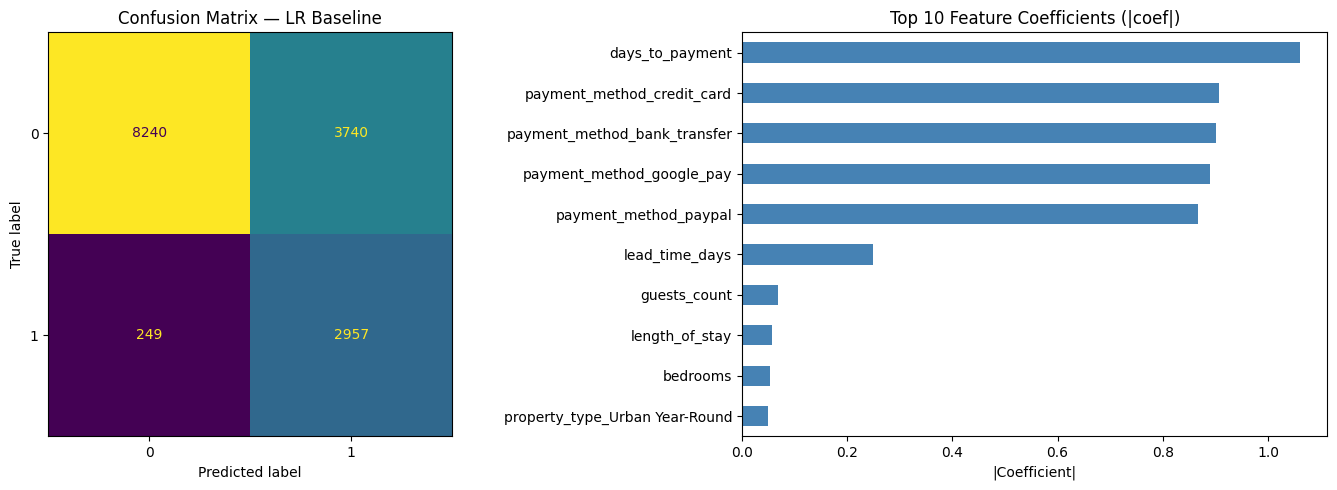

Test AUC: 0.845


In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    lr, X_test, y_test, ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix — LR Baseline')

# Feature coefficients — top 10 by absolute magnitude
coef = pd.Series(
    np.abs(lr.named_steps['clf'].coef_[0]),
    index=X.columns,
)
coef.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Feature Coefficients (|coef|)')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

print('Test AUC: {:.3f}'.format(test_auc))


---
## Section 6 — Save and Load the Model with MLflow

On the Individual (free) edition, we load the model directly from the MLflow run URI — no separate model registry step required.

**What this looks like in a paid workspace:**
```python
mlflow.set_registry_uri('databricks-uc')
mlflow.register_model(model_uri, 'main.default.cancellation_predictor')

# Set a stable alias
client.set_registered_model_alias('main.default.cancellation_predictor', 'champion', version)

# Inference pipelines always reference the alias, not the version number
mlflow.pyfunc.load_model('models:/main.default.cancellation_predictor@champion')
```
When you promote a new model, you move the `@champion` alias. The inference pipeline code never changes.

In [0]:
# Load the model directly from the MLflow run artifact (works on free edition)
model_uri = 'runs:/' + run_id + '/model'
loaded_model = mlflow.sklearn.load_model(model_uri)

# Score 5 test samples — proves the round-trip works
sample_input  = X_test.head(5)
predictions   = loaded_model.predict(sample_input)
probabilities = loaded_model.predict_proba(sample_input)[:, 1]

result = sample_input[['lead_time_days', 'total_amount']].copy()
result['predicted_cancelled']      = predictions
result['cancellation_probability'] = probabilities.round(3)

display(result)

lead_time_days,total_amount,predicted_cancelled,cancellation_probability
7,137.41,1,0.732
23,869.68,1,0.688
96,804.14,0,0.067
386,570.6,0,0.001
97,896.99,1,0.762


---
## Section 7 — CI/CD in Databricks: Conceptual Overview

On the free edition, full CI/CD cannot be demonstrated live — but the pattern is straightforward:

```
Developer pushes notebook/code to GitHub
          |
          v
GitHub Actions triggers on PR or merge to main
          |
          v
databricks bundle deploy  (deploys code to staging workspace)
          |
          v
Databricks Workflow runs automated tests
(unit tests + model quality validation)
          |
          v
On success: model alias promoted to @champion in prod workspace
          |
          v
Inference pipeline always loads @champion -- no code changes needed
```

**Key tools:**

| Tool | Role |
|---|---|
| **Databricks Asset Bundles (DABs)** | Infrastructure-as-code — define notebooks, jobs, clusters in `databricks.yml` |
| **Databricks CLI** | Runs `databricks bundle deploy` from GitHub Actions |
| **MLflow Model Registry** | Model versioning, aliases, and lineage (Unity Catalog — paid feature) |
| **Databricks Workflows** | Orchestration for scheduled and event-triggered jobs |

> You can version this notebook in Git right now — connect via **Repos** in the workspace sidebar and commit/push to GitHub.  
> The multi-environment deployment step requires a trial or paid workspace.

---
## Section 8 — Train Multiple Models & Compare

We benchmark **four classifiers** on the same feature set and split.  
Each model gets its own MLflow run — navigate to **Experiments** → `wanderbricks_cancellation` → **Compare runs**.

| Model | Key strength | Class imbalance handling |
|---|---|---|
| **Logistic Regression** | Baseline from Section 3; coefficients are directly interpretable | `class_weight='balanced'` |
| **Random Forest** | Parallel ensemble of decision trees; robust to outliers | `class_weight='balanced'` |
| **Gradient Boosting** | Sequential ensemble; strong on tabular data | `sample_weight` from `compute_sample_weight` |
| **XGBoost** | Regularised gradient boosting; typically best single model on tabular benchmarks | `scale_pos_weight` = neg / pos ratio |

> **Tip:** After all runs complete, click the **chart icon** in the Experiments UI to see AUC on a bar chart across all four runs.


In [ ]:
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

import os
from mlflow.models.signature import infer_signature

username = os.environ.get('USER', 'unknown')
experiment_path = f'/Users/{username}/wanderbricks_cancellation'
try:
    mlflow.set_experiment(experiment_path)
except Exception:
    mlflow.set_experiment('/wanderbricks_cancellation')

# log_models=False: we log models explicitly below so artifacts reliably exist
# at runs:/run_id/model for all frameworks including XGBoost
mlflow.sklearn.autolog(log_models=False)

model_results = []

# ── Include the LR baseline trained in Section 3 ─────────────────────────────
lr_pred_test   = lr.predict(X_test)
lr_pred_train  = lr.predict(X_train)
lr_auc         = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
lr_test_prec   = precision_score(y_test,  lr_pred_test)
lr_test_rec    = recall_score(y_test,     lr_pred_test)
lr_train_prec  = precision_score(y_train, lr_pred_train)
lr_train_rec   = recall_score(y_train,    lr_pred_train)
lr_importance  = pd.Series(
    np.abs(lr.named_steps['clf'].coef_[0]), index=X.columns
)
model_results.append({
    'model_name':      'LogisticRegression',
    'run_id':          run_id,
    'test_auc':        lr_auc,
    'test_precision':  lr_test_prec,
    'test_recall':     lr_test_rec,
    'train_precision': lr_train_prec,
    'train_recall':    lr_train_rec,
    'importance':      lr_importance,
    'model':           lr,
})
print(f'  [LogisticRegression   ]  AUC={lr_auc:.4f}  test_prec={lr_test_prec:.4f}  test_rec={lr_test_rec:.4f}  (baseline from Section 3)')


def get_importance(model, feature_names):
    """Return feature importances or absolute coefficients for any supported model."""
    estimator = model.named_steps.get('clf') if hasattr(model, 'named_steps') else model
    if hasattr(estimator, 'feature_importances_'):
        return pd.Series(estimator.feature_importances_, index=feature_names)
    elif hasattr(estimator, 'coef_'):
        return pd.Series(np.abs(estimator.coef_[0]), index=feature_names)
    return None


def train_and_log(model, model_name, fit_params=None):
    """Train, explicitly log the model artifact with signature, and record all metrics in MLflow."""
    fit_params = fit_params or {}
    with mlflow.start_run(run_name=model_name) as run:
        model.fit(X_train, y_train, **fit_params)

        # Infer signature from training data — required by Unity Catalog model registry
        signature = infer_signature(X_train, model.predict(X_train))

        # Explicit log_model with signature + input_example ensures UC registration works
        # for all frameworks including XGBoost
        mlflow.sklearn.log_model(
            model, 'model',
            signature=signature,
            input_example=X_train.head(5),
        )

        y_prob      = model.predict_proba(X_test)[:, 1]
        y_pred_test = model.predict(X_test)
        auc            = roc_auc_score(y_test, y_prob)
        test_precision = precision_score(y_test, y_pred_test)
        test_recall    = recall_score(y_test,    y_pred_test)

        y_pred_train    = model.predict(X_train)
        train_precision = precision_score(y_train, y_pred_train)
        train_recall    = recall_score(y_train,    y_pred_train)

        mlflow.log_param('model_type',       model_name)
        mlflow.log_metric('test_roc_auc',    auc)
        mlflow.log_metric('test_precision',  test_precision)
        mlflow.log_metric('test_recall',     test_recall)
        mlflow.log_metric('train_precision', train_precision)
        mlflow.log_metric('train_recall',    train_recall)

        importance = get_importance(model, X_train.columns.tolist())
        if importance is not None:
            fig, ax = plt.subplots(figsize=(8, 5))
            importance.nlargest(10).sort_values().plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'{model_name} — Top 10 Feature Importances')
            ax.set_xlabel('Importance Score')
            plt.tight_layout()
            mlflow.log_figure(fig, 'feature_importance.png')
            plt.close(fig)

        stored_run_id = run.info.run_id

    print(f'  [{model_name:<22}]  AUC={auc:.4f}  '
          f'test_prec={test_precision:.4f}  test_rec={test_recall:.4f}  '
          f'train_prec={train_precision:.4f}  train_rec={train_recall:.4f}')
    return {
        'model_name':      model_name,
        'run_id':          stored_run_id,
        'test_auc':        auc,
        'test_precision':  test_precision,
        'test_recall':     test_recall,
        'train_precision': train_precision,
        'train_recall':    train_recall,
        'importance':      importance,
        'model':           model,
    }


print('\nTraining additional models...')

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, max_depth=8,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
model_results.append(train_and_log(rf, 'RandomForest'))

# ── Gradient Boosting ─────────────────────────────────────────────────────────
gbm = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, random_state=42,
)
sw = compute_sample_weight('balanced', y_train)
model_results.append(train_and_log(gbm, 'GradientBoosting',
                                   fit_params={'sample_weight': sw}))

# ── XGBoost ───────────────────────────────────────────────────────────────────
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='auc', random_state=42,
    verbosity=0,
)
model_results.append(train_and_log(xgb_clf, 'XGBoost'))

print('\nDone. All runs logged to experiment: wanderbricks_cancellation')


In [0]:
# ── Model Comparison Table ────────────────────────────────────────────────────
metric_cols = ['model_name', 'test_auc', 'test_precision', 'test_recall',
               'train_precision', 'train_recall', 'run_id']

comparison_df = (
    pd.DataFrame(model_results)[metric_cols]
    .sort_values('test_auc', ascending=False)
    .reset_index(drop=True)
)
comparison_df.index += 1  # 1-based rank
comparison_df.columns = ['Model', 'Test AUC', 'Test Precision', 'Test Recall',
                          'Train Precision', 'Train Recall', 'Run ID']
for col in ['Test AUC', 'Test Precision', 'Test Recall', 'Train Precision', 'Train Recall']:
    comparison_df[col] = comparison_df[col].round(4)

print('=== Model Leaderboard ===')
print(comparison_df.to_string())

# Highlight overfitting: large gap between train and test precision/recall
print('\n=== Overfitting Check (Train − Test gap) ===')
for r in model_results:
    prec_gap = r['train_precision'] - r['test_precision']
    rec_gap  = r['train_recall']    - r['test_recall']
    flag = '  ⚠ possible overfit' if prec_gap > 0.15 or rec_gap > 0.15 else ''
    print(f"  {r['model_name']:<24}  precision gap={prec_gap:+.4f}  recall gap={rec_gap:+.4f}{flag}")

best = max(model_results, key=lambda r: r['test_auc'])
print(f'\nBest model: {best["model_name"]}  (AUC={best["test_auc"]:.4f})')

=== Model Leaderboard ===
                Model  Test AUC  Test Precision  Test Recall  Train Precision  Train Recall                            Run ID
1             XGBoost    0.8762          0.5428       0.9089           0.5415        0.9107  9a1a797e7c2549aa84eb2d0e8fee619b
2    GradientBoosting    0.8752          0.5429       0.9080           0.5423        0.9106  56f4168486b84586ba6c743360195537
3        RandomForest    0.8614          0.5422       0.9102           0.5388        0.9077  26ed3f2f24524d24bed613d4778db069
4  LogisticRegression    0.8450          0.4415       0.9223           0.4400        0.9214  fbab8694d738438c9997cefcd0cf4eeb

=== Overfitting Check (Train − Test gap) ===
  LogisticRegression        precision gap=-0.0015  recall gap=-0.0009
  RandomForest              precision gap=-0.0034  recall gap=-0.0024
  GradientBoosting          precision gap=-0.0006  recall gap=+0.0026
  XGBoost                   precision gap=-0.0014  recall gap=+0.0018

Best model: XGBoo

---
## Section 9 — Feature Importance Comparison

Plotting all four models side-by-side reveals which signals are universally important vs model-specific.

- **Tree models** (RF, GBM, XGB): importance = mean decrease in impurity across all splits on that feature
- **Logistic Regression**: importance = absolute value of the coefficient (after standardisation — units are comparable)

A feature that ranks highly in *all* models is a robust, trustworthy signal.  
A feature that only matters to one model may be capturing noise or a model-specific artifact.

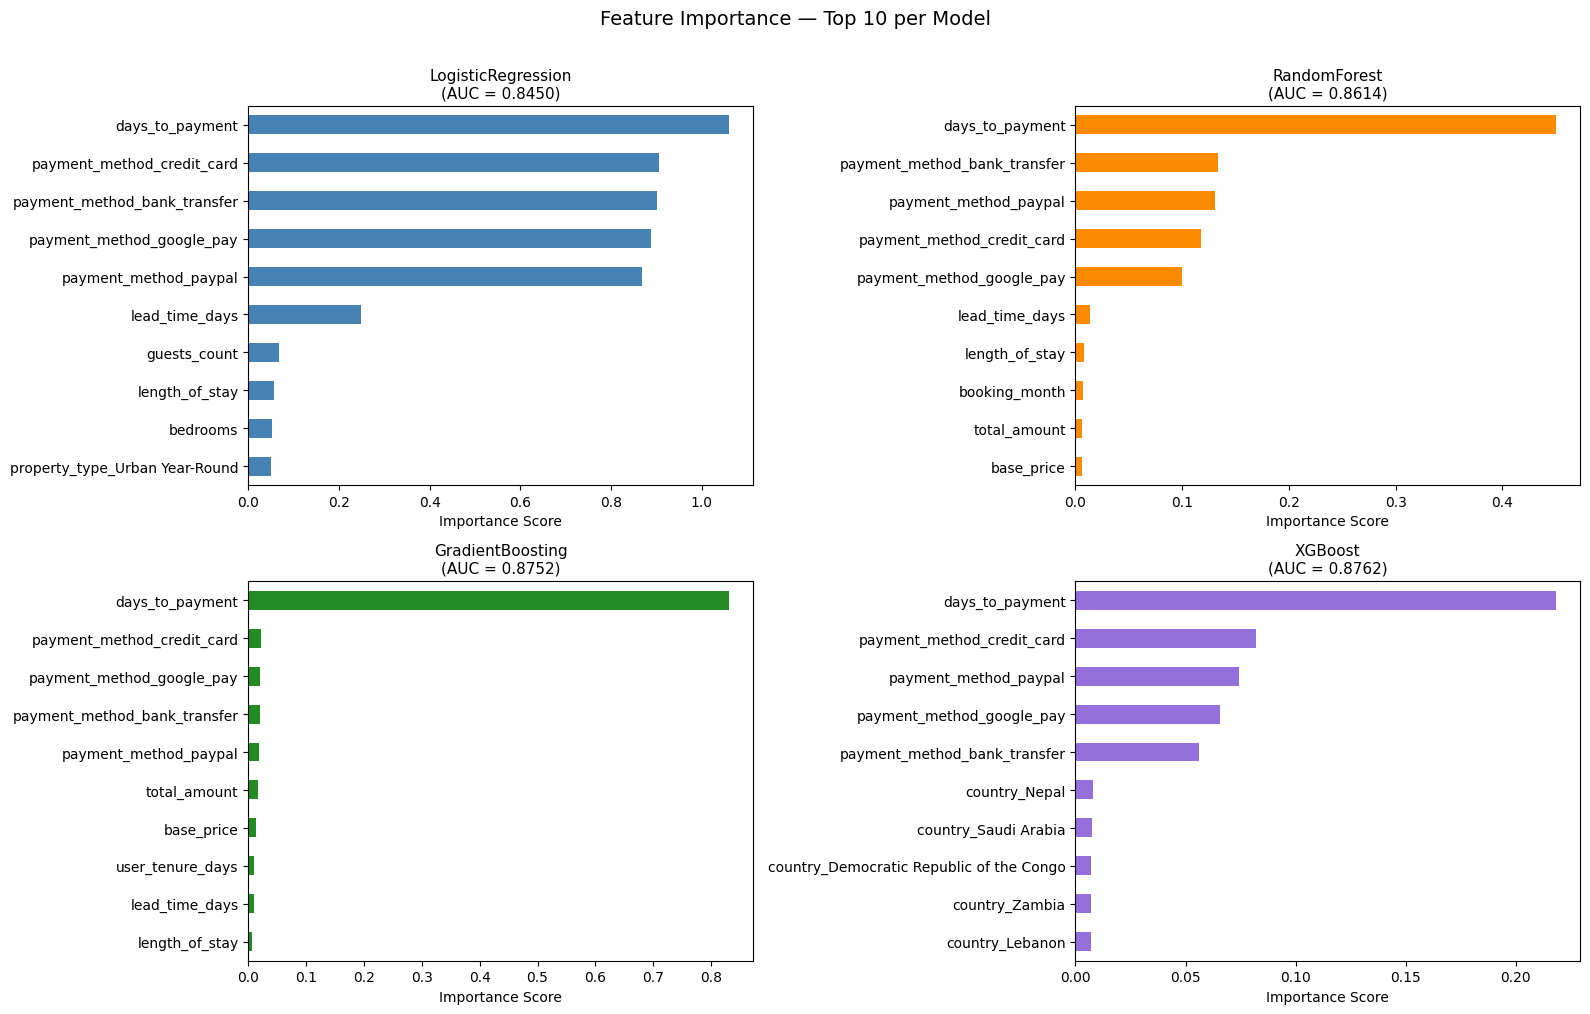


Features in the top-10 of ALL models (universal signals):
  days_to_payment
  payment_method_bank_transfer
  payment_method_credit_card
  payment_method_google_pay
  payment_method_paypal


In [0]:
# ── Side-by-side feature importance for all models ───────────────────────────
models_with_importance = [r for r in model_results if r.get('importance') is not None]

if not models_with_importance:
    print('⚠ No feature importance data available.')
    print('\nFeature importance is only computed when Cell 22 (Section 8) has been run.')
    print('To see feature importance:')
    print('  1. Run Cell 22 (Section 8) to train all 4 models')
    print('  5. Re-run Cell 24 to register models')
    print('  3. Re-run this cell to visualize feature importance')
else:
    cols = 2
    rows = (len(models_with_importance) + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten()
    
    colors = ['steelblue', 'darkorange', 'forestgreen', 'mediumpurple']
    
    for i, result in enumerate(models_with_importance):
        imp   = result['importance']
        top10 = imp.nlargest(10).sort_values()
        top10.plot(kind='barh', ax=axes[i], color=colors[i % len(colors)])
        axes[i].set_title(f'{result["model_name"]}\n(AUC = {result["test_auc"]:.4f})', fontsize=11)
        axes[i].set_xlabel('Importance Score')
    
    # Hide any unused subplots
    for j in range(len(models_with_importance), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Feature Importance — Top 10 per Model', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # ── Aggregate: which features appear in every model's top 10? ────────────────
    top10_sets = [set(r['importance'].nlargest(10).index) for r in models_with_importance]
    universal  = set.intersection(*top10_sets) if top10_sets else set()
    print('\nFeatures in the top-10 of ALL models (universal signals):')
    for f in sorted(universal):
        print(' ', f)

---
## Section 10 — Register All Models in the MLflow Model Registry

The **Model Registry** is the handoff point between experimentation and production.  
Every model is registered as a new version under the same name — so the **Models tab** shows all versions, their metrics, and their current alias in one place.

**Workflow:**
```
Train (experiment run)  →  Register (Model Registry)  →  Assign alias  →  Inference pipeline loads @champion
```

**Aliases vs version numbers:**
- Version numbers auto-increment every time you register. Never hardcode them in inference code.
- Aliases (`@champion`, `@challenger`) are stable pointers you move between versions. Promote a new model by moving the alias — no pipeline code changes needed.

> On the **free Databricks edition**: models register to the workspace-level registry (visible in the **Models** tab in the left sidebar).  
> On **paid / Trial with Unity Catalog**: prefix the model name with a three-level namespace, e.g. `main.ml.cancellation_predictor`, and set `mlflow.set_registry_uri('databricks-uc')` first.

In [0]:
import os
from mlflow import MlflowClient
import mlflow

client        = MlflowClient()
username      = os.environ.get('USER', 'unknown').replace('@', '_').replace('.', '_')
REGISTRY_NAME = f'workspace.default.wanderbricks_cancellation_predictor_{username}'

try:
    model_results
    print(f'Registering all {len(model_results)} models as versions of: {REGISTRY_NAME}\n')
except NameError:
    print('⚠ model_results not found. Please run Cell 22 (Section 8) first.')
    print('\nFalling back: registering only the Logistic Regression baseline from Section 3.\n')

    lr_pred_test  = lr.predict(X_test)
    lr_pred_train = lr.predict(X_train)
    lr_auc        = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
    lr_test_prec  = precision_score(y_test, lr_pred_test)
    lr_test_rec   = recall_score(y_test, lr_pred_test)
    lr_train_prec = precision_score(y_train, lr_pred_train)
    lr_train_rec  = recall_score(y_train, lr_pred_train)

    model_results = [{
        'model_name':      'LogisticRegression',
        'run_id':          run_id,
        'test_auc':        lr_auc,
        'test_precision':  lr_test_prec,
        'test_recall':     lr_test_rec,
        'train_precision': lr_train_prec,
        'train_recall':    lr_train_rec,
    }]
    print(f'Registering LogisticRegression model as: {REGISTRY_NAME}\n')

registered = []

for result in model_results:
    model_uri = f'runs:/{result["run_id"]}/model'
    mv = mlflow.register_model(model_uri=model_uri, name=REGISTRY_NAME)
    client.set_model_version_tag(REGISTRY_NAME, mv.version, 'model_type',   result['model_name'])
    client.set_model_version_tag(REGISTRY_NAME, mv.version, 'test_roc_auc', f'{result["test_auc"]:.4f}')
    registered.append({'model_name': result['model_name'], 'version': mv.version,
                       'test_auc': result['test_auc'], 'run_id': result['run_id']})
    print(f'  Registered {result["model_name"]:<24} → version {mv.version}  (AUC={result["test_auc"]:.4f})')

best_entry = max(registered, key=lambda r: r['test_auc'])
print(f'\nBest model: {best_entry["model_name"]}  v{best_entry["version"]}  (AUC={best_entry["test_auc"]:.4f})')

client.set_registered_model_alias(
    name    = REGISTRY_NAME,
    alias   = 'champion',
    version = best_entry['version'],
)
print(f'\n@champion alias → {best_entry["model_name"]} (version {best_entry["version"]})')
print(f'\nNavigate to: Models tab (left sidebar) → {REGISTRY_NAME}')
print('You will see all versions with tags, AUC, and the @champion alias.')

champion_version = best_entry['version']


Registering all 4 models as versions of: workspace.default.wanderbricks_cancellation_predictor_spark-853b41aa-a762-40ce-bb8d-85



Successfully registered model 'workspace.default.wanderbricks_cancellation_predictor_spark-853b41aa-a762-40ce-bb8d-85'.
2026/08/17 02:59:49 WARNING mlflow.tracking._model_registry.fluent: Run with id fbab8694d738438c9997cefcd0cf4eeb has no artifacts at artifact path 'model', registering model based on models:/m-78dead7cc1a9433bb1d2634bc3767cc3 instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.wanderbricks_cancellation_predictor_spark-853b41aa-a762-40ce-bb8d-85': https://dbc-a030f00c-1607.cloud.databricks.com/explore/data/models/workspace/default/wanderbricks_cancellation_predictor_spark-853b41aa-a762-40ce-bb8d-85/version/1?o=7474656619128549


  Registered LogisticRegression       → version 1  (AUC=0.8450)


Registered model 'workspace.default.wanderbricks_cancellation_predictor_spark-853b41aa-a762-40ce-bb8d-85' already exists. Creating a new version of this model...
2026/08/17 02:59:54 WARNING mlflow.tracking._model_registry.fluent: Run with id 26ed3f2f24524d24bed613d4778db069 has no artifacts at artifact path 'model', registering model based on models:/m-917c3b6b32fd447da61ae2558824e2fe instead


---------------------------------------------------------------------------
MlflowException                           Traceback (most recent call last)
File <command-8067067884657619>, line 39
     37 for result in model_results:
     38     model_uri = f'runs:/{result["run_id"]}/model'
---> 39     mv = mlflow.register_model(model_uri=model_uri, name=REGISTRY_NAME)
     40     client.set_model_version_tag(REGISTRY_NAME, mv.version, 'model_type',   result['model_name'])
     41     client.set_model_version_tag(REGISTRY_NAME, mv.version, 'test_roc_auc', f'{result["test_auc"]:.4f}')

File /databricks/python/lib/python3.12/site-packages/mlflow/tracking/_model_registry/fluent.py:136, in register_model(model_uri, name, await_registration_for, tags, env_pack)
     66 def register_model(
     67     model_uri,
     68     name,
   (...)
     72     env_pack: EnvPackType | EnvPackConfig | None = None,
     73 ) -> ModelVersion:
     74     """Create a new model version in model registry for the

In [0]:
import os
client        = MlflowClient()

# Unity Catalog requires three-level naming: catalog.schema.model_name
username = os.environ.get("USER", "unknown").replace("@", "_").replace(".", "_")
REGISTRY_NAME = f'workspace.default.wanderbricks_cancellation_predictor_{username}'

# ── How to promote a new champion (e.g. after next retraining cycle) ─────────
#
# 1. Train new model, get its run_id
# 2. Register it:
#       new_mv = mlflow.register_model('runs:/<new_run_id>/model', REGISTRY_NAME)
# 3. Evaluate, then promote:
#       client.set_registered_model_alias(REGISTRY_NAME, 'champion', new_mv.version)
# 4. The serving endpoint (if configured) immediately picks up the new version.
#    No code changes needed anywhere in the inference pipeline.
#
# To inspect current registry state:
print(f'All registered versions of {REGISTRY_NAME}:\n')
try:
    versions = list(client.search_model_versions(f"name='{REGISTRY_NAME}'"))
    if not versions:
        print(f'  (No versions registered yet. Run Cell 24 to register models.)')
    for mv in versions:
        tags    = mv.tags
        aliases = ', '.join(mv.aliases) if mv.aliases else '—'
        print(f'  v{mv.version:<4}  {tags.get("model_type",""):<24}  AUC={tags.get("test_roc_auc","?")}  aliases=[{aliases}]  run={mv.run_id[:8]}...')
except Exception as e:
    print(f'  Error querying registry: {e}')

---
## Section 11 — Serve the Champion Model

### Option A — Batch scoring (works on free edition)

Load the `@champion` alias and score a DataFrame directly in the notebook.  
This is the pattern for nightly batch jobs: load once, score millions of rows.

### Option B — Real-time REST endpoint (paid / Trial workspace only)

```
Serving tab (left sidebar) → Create serving endpoint
  Model: wanderbricks_cancellation_predictor
  Served entity: @champion   ← always follows the alias
  Compute: Small (for demo)
```

The endpoint auto-scales and exposes a `/invocations` REST API:
```bash
curl -X POST https://<workspace-url>/serving-endpoints/cancellation-predictor/invocations \
  -H 'Authorization: Bearer <token>' \
  -H 'Content-Type: application/json' \
  -d '{"dataframe_records": [{"lead_time_days": 45, "total_amount": 320.0, ...}]}'
```

**Why alias-based serving?**  
When you promote a new champion (e.g. next month's retrained XGBoost), you move the `@champion` alias.  
The endpoint immediately serves the new version — zero config change, zero downtime.

In [0]:
# ── Option A: Load @champion and batch-score ─────────────────────────────────
# Check if models have been registered yet
try:
    versions = list(client.search_model_versions(f"name='{REGISTRY_NAME}'"))
    if not versions:
        print('⚠ No models registered yet.')
        print('\nTo use this cell, first:')
        print('  1. Run Cell 22 (Section 8) to train all 4 models (takes ~2 min)')
        print('  2. Run Cell 27 (Section 10) to register them and assign @champion alias')
        print('  3. Re-run this cell to load and score with the champion')
    else:
        champion_uri   = f'models:/{REGISTRY_NAME}@champion'
        champion_model = mlflow.sklearn.load_model(champion_uri)
        
        # Get champion version for display
        champion_versions = [v for v in versions if 'champion' in v.aliases]
        champion_version = champion_versions[0].version if champion_versions else 'unknown'
        
        print(f'Loaded champion: {REGISTRY_NAME}@champion  (version {champion_version})')
        print(f'Model type: {type(champion_model).__name__}\n')
        
        # Score the full test set
        y_prob_champion = champion_model.predict_proba(X_test)[:, 1]
        y_pred_champion = champion_model.predict(X_test)
        
        final_auc = roc_auc_score(y_test, y_prob_champion)
        print(f'Champion Test AUC: {final_auc:.4f}')
        
        # Show top 10 highest-risk bookings in the test set
        risk_df = X_test[['lead_time_days', 'total_amount', 'length_of_stay']].copy()
        risk_df['cancel_probability'] = y_prob_champion.round(4)
        risk_df['predicted_cancel']   = y_pred_champion
        risk_df['actual_cancel']      = y_test.values
        
        top_risk = risk_df.sort_values('cancel_probability', ascending=False).head(10)
        print('\nTop 10 highest-risk bookings (champion model):')
        display(top_risk)
except Exception as e:
    print(f'⚠ Error: {e}')
    print('\nTo use this cell, first:')
    print('  1. Run Cell 22 (Section 8) to train all 4 models (takes ~2 min)')
    print('  2. Run Cell 27 (Section 10) to register them and assign @champion alias')
    print('  3. Re-run this cell to load and score with the champion')

---
## Summary

| Step | What we used | Why it matters |
|---|---|---|
| Data access | `spark.read.table()` + `samples` catalog | No connection strings; governed access |
| Feature engineering | PySpark `withColumn()`, `datediff()` | Scalable; same code works on billions of rows |
| Model training | `RandomForestClassifier` + `mlflow.sklearn.autolog()` | Full experiment tracking in one line |
| Multi-model benchmark | LR, GBM, XGBoost, RandomForest | Compare algorithms on equal footing |
| Feature importance | `feature_importances_`, `coef_` | Understand *why* the model predicts what it does |
| Experiment tracking | MLflow Experiments UI | Reproducible, auditable, comparable runs |
| Model Registry | `mlflow.register_model()` + aliases | Stable `@champion` pointer — no version hardcoding |
| Batch serving | `mlflow.sklearn.load_model('models:/...@champion')` | Load once, score any DataFrame |
| Real-time serving | Databricks Serving endpoint (paid feature) | REST API with auto-scaling; alias-driven promotion |
| CI/CD | Databricks Asset Bundles + GitHub Actions | Automated, governed ML deployment |

**Try next:**
- In the **Models tab**: click `wanderbricks_cancellation_predictor` → compare versions → manually re-assign `@champion` to a different version
- In the **Experiments tab**: select all four runs → click **Compare** → chart `test_roc_auc` across runs
- Tune XGBoost hyperparameters and re-register — watch the version list grow
- Explore **Databricks AutoML** for automated feature engineering and model selection